# Diversidade e apoio socioeducativo — Agrupamento de Escolas Francisco de Arruda

**Escola TEIP (Território Educativo de Intervenção Prioritária)**, Ajuda, Lisboa.

Este notebook analisa dados anonimizados de **463 alunos** em **23 turmas** (5º ao 9º ano + PIEF),
recolhidos no âmbito do processo de atualização de dados para o sistema Inovar (jun-ago 2026).

Nenhum dado pessoal identificável (nomes, documentos, contactos) é usado nesta análise —
ver `src/anonymize.py` para a metodologia de anonimização completa.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

import analysis as an
import style

style.apply_mpl_style()
df = an.load_data()
an.overview(df)

{'total_alunos': 463,
 'total_turmas': 23,
 'anos_escolaridade': ['5', '6', '7', '8', '9', 'PIEF 6', 'PIEF 9']}

## 1. Visão geral

Total de alunos: 463
Total de turmas: 23
Anos de escolaridade: 5, 6, 7, 8, 9, PIEF 6, PIEF 9


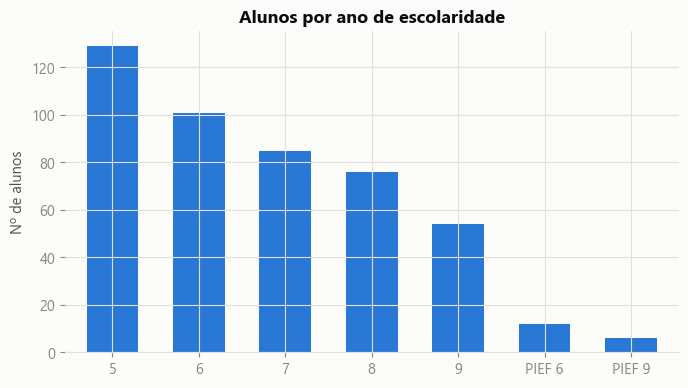

In [2]:
ov = an.overview(df)
print(f"Total de alunos: {ov['total_alunos']}")
print(f"Total de turmas: {ov['total_turmas']}")
print(f"Anos de escolaridade: {', '.join(ov['anos_escolaridade'])}")

df.groupby("ano_escolaridade").size().reindex(ov["anos_escolaridade"]).plot(
    kind="bar", figsize=(7, 4), color=style.CATEGORICAL[0], width=0.6
)
plt.title("Alunos por ano de escolaridade")
plt.xlabel("")
plt.ylabel("Nº de alunos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Rácio Português vs. estrangeiro

Uma escola TEIP tipicamente serve populações mais diversas — o gráfico confirma isso.
Alunos sem nacionalidade registada (13.8%) são excluídos do rácio, para não distorcer a
proporção real (ver nota de qualidade de dados na secção 6).

grupo_nacionalidade
Portuguesa     65.4
Estrangeira    34.6
Name: count, dtype: float64


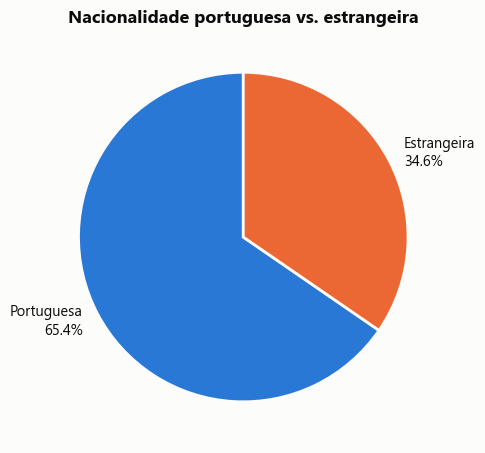

In [3]:
ratio = an.pt_vs_estrangeira(df)
pct = (ratio / ratio.sum() * 100).round(1)
print(pct)

colors = [style.PORTUGUESA, style.ESTRANGEIRA]
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(ratio, labels=[f"{i}\n{p}%" for i, p in zip(ratio.index, pct)],
       colors=colors, startangle=90, wedgeprops={"linewidth": 2, "edgecolor": style.SURFACE})
ax.set_title("Nacionalidade portuguesa vs. estrangeira")
plt.tight_layout()
plt.show()

## 3. Nacionalidades representadas

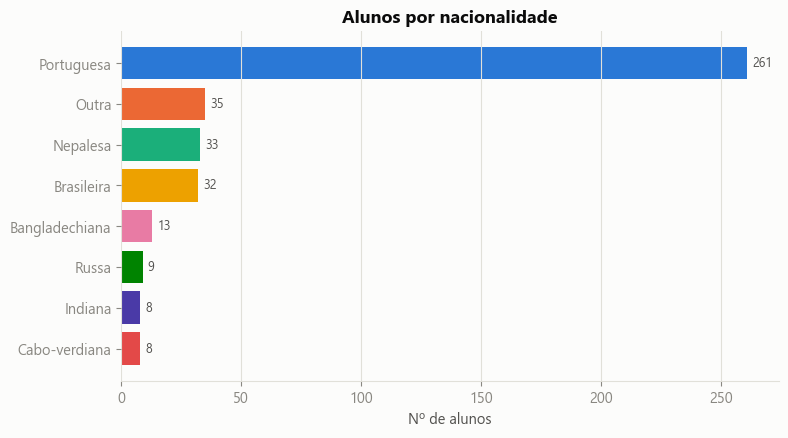

Índice de diversidade (Simpson): 0.553
(0 = uma só nacionalidade; quanto mais perto de 1, mais diversa a escola)


In [4]:
nat = an.nationality_breakdown(df, top_n=7)
colors = (style.CATEGORICAL * 2)[: len(nat)]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(nat.index[::-1], nat.values[::-1], color=colors[::-1])
ax.set_title("Alunos por nacionalidade")
ax.set_xlabel("Nº de alunos")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
for i, v in enumerate(nat.values[::-1]):
    ax.text(v + 2, i, str(v), va="center", color=style.INK_SECONDARY, fontsize=9)
plt.tight_layout()
plt.show()

print(f"Índice de diversidade (Simpson): {an.simpson_diversity_index(df)}")
print("(0 = uma só nacionalidade; quanto mais perto de 1, mais diversa a escola)")

## 4. Indicadores TEIP: apoio socioeconómico (ASE)

A Ação Social Escolar (ASE) é o principal indicador de vulnerabilidade socioeconómica
disponível nestes dados — central à missão de um agrupamento TEIP.

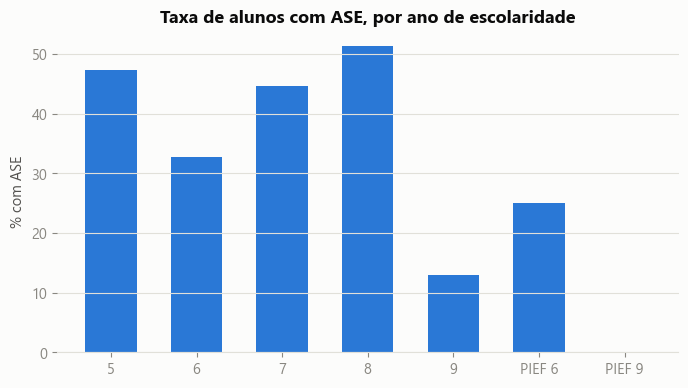

                      ate   ase   rtp  pei  tem_pc  tem_internet
grupo_nacionalidade                                             
Estrangeira          14.5  28.3   7.2  2.9    29.0          63.0
Portuguesa            7.7  54.4  13.8  6.9    36.8          74.3


In [5]:
ase_by_year = an.rate_by_group(df, "ase")
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ase_by_year.index, ase_by_year.values, color=style.CATEGORICAL[0], width=0.6)
ax.set_title("Taxa de alunos com ASE, por ano de escolaridade")
ax.set_ylabel("% com ASE")
plt.tight_layout()
plt.show()

needs = an.support_needs_by_nationality(df)
print(needs)

## 5. Literacia digital: acesso a computador e internet em casa

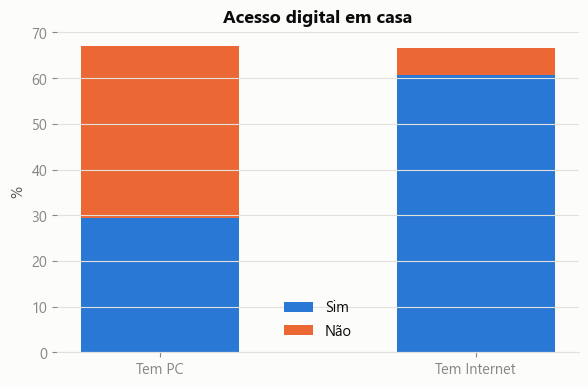

In [6]:
pc = an.yn_overall_rate(df, "tem_pc")
net = an.yn_overall_rate(df, "tem_internet")

fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Tem PC", "Tem Internet"]
sim_vals = [pc.get("Sim", 0), net.get("Sim", 0)]
nao_vals = [pc.get("Não", 0), net.get("Não", 0)]
x = range(len(labels))
ax.bar(x, sim_vals, color=style.SIM, label="Sim", width=0.5)
ax.bar(x, nao_vals, bottom=sim_vals, color=style.NAO, label="Não", width=0.5)
ax.set_xticks(list(x), labels)
ax.set_ylabel("%")
ax.set_title("Acesso digital em casa")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 6. Necessidades de apoio e qualidade dos dados

In [7]:
for col in ["rtp", "pei"]:
    print(col.upper(), an.yn_overall_rate(df, col))

print()
print("Condição de saúde referida:", df["tem_condicao_saude"].mean().round(3) * 100, "%")
print("Restrição alimentar referida:", df["tem_restricao_alimentar"].mean().round(3) * 100, "%")

RTP {'Não': np.float64(55.1), 'N/A': np.float64(35.0), 'Sim': np.float64(9.9)}
PEI {'Não': np.float64(59.0), 'N/A': np.float64(36.3), 'Sim': np.float64(4.8)}

Condição de saúde referida: 100.0 %
Restrição alimentar referida: 100.0 %


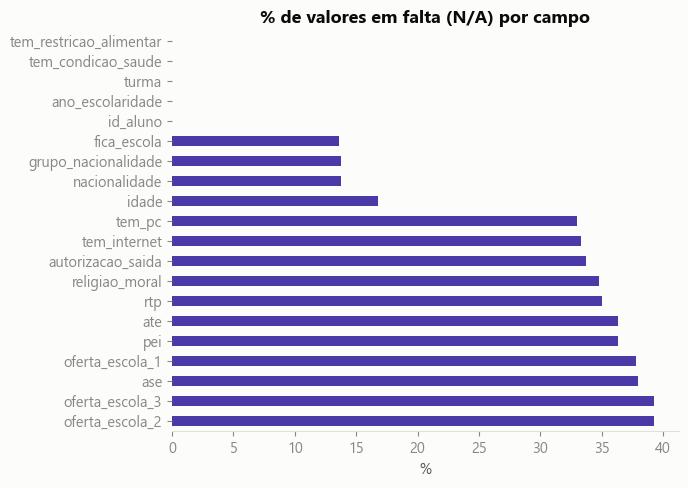

Nota: idade calculada só é fiável para 385 de 463 alunos — datas de nascimento em falta ou implausíveis na fonte


In [8]:
missing = an.missing_data_rates(df)
fig, ax = plt.subplots(figsize=(7, 5))
missing.plot(kind="barh", ax=ax, color=style.CATEGORICAL[6])
ax.set_title("% de valores em falta (N/A) por campo")
ax.set_xlabel("%")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print("Nota: idade calculada só é fiável para", df['idade'].notna().sum(),
      "de", len(df), "alunos — datas de nascimento em falta ou implausíveis na fonte")

## Conclusões

- A escola serve uma população claramente diversa, com mais de 10 nacionalidades
  representadas e um rácio de cerca de 1 em cada 3 alunos de nacionalidade estrangeira
  (entre os que têm nacionalidade registada).
- A taxa de ASE varia consideravelmente por ano de escolaridade e é claramente mais baixa
  entre alunos estrangeiros — um sinal a investigar (pode refletir menor adesão/candidatura
  ao ASE, não necessariamente menor necessidade).
- O acesso a internet em casa é consideravelmente mais alto do que o acesso a computador —
  relevante para qualquer estratégia de ensino que dependa de dispositivos próprios.
- A qualidade dos dados de origem tem lacunas relevantes (nacionalidade e data de nascimento
  em falta numa fração not-trivial dos registos) — uma oportunidade de melhoria de processo
  para o preenchimento no Inovar.